In [1]:
import torch
# Load model directly
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from huggingface_hub import login
# login("my secret token ;)") make sure to put your secrets in


tokenizer = AutoTokenizer.from_pretrained("mideind/IceBERT")
model = AutoModelForSequenceClassification.from_pretrained("mideind/IceBERT", num_labels=2)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: mideind/IceBERT
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [2]:
folder = "data/"

import json
import os
import pandas as pd

ephish_filename = "ephish_emails.json"
icelandic_filename = "icelandic_llm_emails.json"

# Construct full paths to the JSON files
full_ephish_path = os.path.join(folder, ephish_filename)
full_icelandic_path = os.path.join(folder, icelandic_filename)

def load_emails_from_file(filepath, origin_tag):
    if not os.path.exists(filepath):
        print(f"Warning: File not found at {filepath}")
        return []
    with open(filepath, 'r', encoding='utf-8') as f:
        emails = json.load(f)
        print(f"Loaded {len(emails)} emails from {os.path.basename(filepath)}")
        return emails

icelandic_emails_raw = load_emails_from_file(full_icelandic_path, 'icelandic')

icelandic = pd.DataFrame(icelandic_emails_raw)

print(icelandic)

icelandic['Text'] = icelandic['Subject'].fillna('') + ' ' + icelandic['Body'].fillna('')


print(f"Found {len(icelandic)} emails from 'icelandic' dataset.")

# tokenize each column
icelandic['tokenized_body'] = icelandic['Text'].apply(lambda x: tokenizer.encode(x, add_special_tokens=True))

icelandic

Loaded 2877 emails from icelandic_llm_emails.json
                                                   Body  type  \
0     Sæl Edda,\n\nHvernig gengur AI flota stjórnuna...     0   
1     Sæl Birna,\n\nGott starf með átak okkar á samf...     0   
2     Kæri notandi,\n\nVið viljum vekja athygli þína...     1   
3     Kæri þátttakandi,\n\nVið vonum að þú sért ánæg...     1   
4     Kæri Johann Petursson,\n\nVið vonum að allt ga...     1   
...                                                 ...   ...   
2872  Kæra Elena Björnsdóttir,\n\nVonast er til að þ...     1   
2873  Kæri viðtakandi,\n\nÞað gleður okkur á Loka-up...     1   
2874  Sæll Ívar,\n\nÉg hef verið að vinna við að gre...     0   
2875  Kæra Hilmariina Rasmus,\n\nÉg vona að þessi tö...     1   
2876  Kæra Katla Sigurðardóttir,\n\nÉg vona að þessi...     1   

                                                Subject  
0      Staða og áfangar í AI flota stjórnunarverkefninu  
1     Uppfærslur á samfélagsmiðla herferð - tillögur.

,Body,type,Subject,Text,tokenized_body
0,"Sæl Edda,\n\nHvernig gengur AI flota stjórnuna...",0,Staða og áfangar í AI flota stjórnunarverkefninu,Staða og áfangar í AI flota stjórnunarverkefni...,"[0, 17934, 291, 10076, 264, 290, 433, 45, 2833..."
1,"Sæl Birna,\n\nGott starf með átak okkar á samf...",0,Uppfærslur á samfélagsmiðla herferð - tillögur...,Uppfærslur á samfélagsmiðla herferð - tillögur...,"[0, 3247, 16676, 283, 33253, 23059, 483, 4042,..."
2,"Kæri notandi,\n\nVið viljum vekja athygli þína...",1,Brýnt: Öryggisbrot á Google reikningnum þínum,Brýnt: Öryggisbrot á Google reikningnum þínum ...,"[0, 46299, 30, 22473, 2479, 283, 17189, 34269,..."
3,"Kæri þátttakandi,\n\nVið vonum að þú sért ánæg...",1,Fáðu þína umbun fyrir þátttöku í könnun,Fáðu þína umbun fyrir þátttöku í könnun Kæri þ...,"[0, 42, 9518, 9209, 48060, 354, 5420, 290, 494..."
4,"Kæri Johann Petursson,\n\nVið vonum að allt ga...",1,Mikilvæg öryggisuppfærsla fyrir hönnunarhugbúnað,Mikilvæg öryggisuppfærsla fyrir hönnunarhugbún...,"[0, 10933, 3575, 3546, 17073, 354, 12889, 1949..."
...,...,...,...,...,...
2872,"Kæra Elena Björnsdóttir,\n\nVonast er til að þ...",1,Brýn millifærsla fyrir mikilvægt verkefni,Brýn millifærsla fyrir mikilvægt verkefni Kæra...,"[0, 34958, 82, 1009, 17073, 354, 2426, 1994, 4..."
2873,"Kæri viðtakandi,\n\nÞað gleður okkur á Loka-up...",1,Frábær tilboð á íslenskum hráefnum – Sparaðu s...,Frábær tilboð á íslenskum hráefnum – Sparaðu s...,"[0, 30834, 4190, 283, 3244, 6185, 1981, 1126, ..."
2874,"Sæll Ívar,\n\nÉg hef verið að vinna við að gre...",0,Uppgötvanir um efni við öfgafullar aðstæður,Uppgötvanir um efni við öfgafullar aðstæður Sæ...,"[0, 3247, 48567, 90, 1107, 330, 1706, 332, 151..."
2875,"Kæra Hilmariina Rasmus,\n\nÉg vona að þessi tö...",1,Viðkæmur viðskiptafyrirsvarsbeiðni - Brýn aðge...,Viðkæmur viðskiptafyrirsvarsbeiðni - Brýn aðge...,"[0, 822, 79, 490, 276, 6060, 15863, 3554, 1564..."


In [3]:
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer

# Convert tokenized_body lists to dictionary format expected by Dataset, including labels
def prepare_data_for_dataset(df):
    return [{'input_ids': tokens, 'labels': label} for tokens, label in zip(df['tokenized_body'], df['type'])]

# Create Hugging Face Dataset objects
icelandic_dataset_dict = Dataset.from_list(prepare_data_for_dataset(icelandic))

# Split the dataset into training and validation sets
train_test_split_ratio = 0.8
split_result = icelandic_dataset_dict.train_test_split(test_size=1-train_test_split_ratio, seed=42) # Added seed for reproducibility
train_dataset = split_result['train']
eval_dataset = split_result['test']

print(f"Training dataset size: {len(train_dataset)}")
print(f"Evaluation dataset size: {len(eval_dataset)}")

# Initialize data collator for Sequence Classification
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding=True,
    max_length=tokenizer.model_max_length,
    return_tensors="pt" # Return PyTorch tensors
)

# Define training arguments with necessary parameters for classification
training_args = TrainingArguments(
    output_dir="./icebert_finetuned_classifier", # directory for storing logs and checkpoints
    num_train_epochs=3, # adjust as needed
    per_device_train_batch_size=8, # adjust as needed
    logging_steps=500, # Log training metrics every 500 steps
)

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
)

# Start fine-tuning
print("\nStarting fine-tuning...")
trainer.train()
print("Fine-tuning complete!")



Training dataset size: 2301
Evaluation dataset size: 576


[RANK 0] Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.



Starting fine-tuning...


/hpchome/axels22/hf_env/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:2341: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


Step,Training Loss
500,0.158960


...

/hpchome/axels22/hf_env/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:2341: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuning complete!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./fine_tuned_icebert_classifier/tokenizer_config.json',
 './fine_tuned_icebert_classifier/tokenizer.json')

In [4]:
from collections import Counter

# Calculate class distribution for training dataset
train_labels = [item['labels'] for item in train_dataset]
train_label_counts = Counter(train_labels)
total_train_samples = len(train_labels)

print("\n--- Training Dataset Class Distribution ---")
for label, count in sorted(train_label_counts.items()):
    ratio = count / total_train_samples
    print(f"Type {label}: {count} samples ({ratio:.2%})")

# Calculate class distribution for evaluation dataset
eval_labels = [item['labels'] for item in eval_dataset]
eval_label_counts = Counter(eval_labels)
total_eval_samples = len(eval_labels)

print("\n--- Evaluation Dataset Class Distribution ---")
for label, count in sorted(eval_label_counts.items()):
    ratio = count / total_eval_samples
    print(f"Type {label}: {count} samples ({ratio:.2%})")


--- Training Dataset Class Distribution ---
Type 0: 1133 samples (49.24%)
Type 1: 1168 samples (50.76%)

--- Evaluation Dataset Class Distribution ---
Type 0: 304 samples (52.78%)
Type 1: 272 samples (47.22%)


In [5]:
from transformers import AutoModelForSequenceClassification
import transformers

# Reload the saved model
model = AutoModelForSequenceClassification.from_pretrained("./fine_tuned_icebert_classifier")
tokenizer = AutoTokenizer.from_pretrained("./fine_tuned_icebert_classifier")

# Fresh trainer with the loaded model
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
)

# Manually remove the notebook callback that's causing the fuss
trainer.remove_callback(transformers.utils.notebook.NotebookProgressCallback)

# Now evaluate
eval_results = trainer.evaluate()
print("Evaluation results:", eval_results)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[RANK 0] Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
/hpchome/axels22/hf_env/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:2341: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


Evaluation results: {'eval_loss': 0.07012281566858292, 'eval_model_preparation_time': 0.0037, 'eval_runtime': 2.782, 'eval_samples_per_second': 207.047, 'eval_steps_per_second': 25.881, 'epoch': 0}


/hpchome/axels22/hf_env/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:2341: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


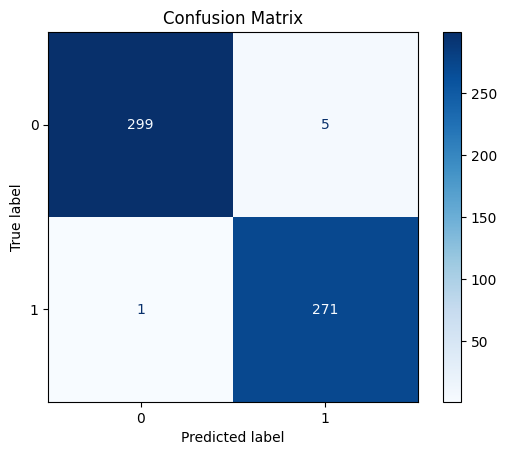

In [6]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get predictions from the trainer
predictions = trainer.predict(eval_dataset)

# The predictions object contains logits, which need to be converted to class labels
logits = predictions.predictions
predicted_labels = np.argmax(logits, axis=-1)

# Get true labels
true_labels = eval_dataset['labels']

# Compute confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

Starting experiment with 9 distributions...
Total normal samples available: 1437
Total phishing samples available: 1440

Processing distribution 9:1 (Type 0:Type 1). Actual samples: Type 0=1293, Type 1=144. Total: 1437
Class distribution in current dataset:
 type
0    1293
1     144
Name: count, dtype: int64
Training dataset size for 9:1: 1293
Evaluation dataset size for 9:1: 144


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: mideind/IceBERT
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[RANK 0] Dete

  Training IceBERT for ratio 9:1...


/hpchome/axels22/hf_env/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:2341: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


...

RobertaForSequenceClassification LOAD REPORT from: mideind/IceBERT
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[RANK 0] Dete

  Training IceBERT for ratio 1:9...


/hpchome/axels22/hf_env/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:2341: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


Step,Training Loss


    F1 (Class 0): 0.8182, Precision (Class 0): 0.9000, Recall (Class 0): 0.7500
    F1 (Class 1): 0.9850, Precision (Class 1): 0.9776, Recall (Class 1): 0.9924

--- Experiment Results Summary ---
Distribution_Ratio_Type0_Type1  Type1_Proportion   Model  F1_Class_0  Precision_Class_0  Recall_Class_0  F1_Class_1  Precision_Class_1  Recall_Class_1
                           9:1               0.1 IceBERT    0.992308           0.992308        0.992308    0.928571           0.928571        0.928571
                           8:2               0.2 IceBERT    0.978166           0.982456        0.973913    0.915254           0.900000        0.931034
                           7:3               0.3 IceBERT    1.000000           1.000000        1.000000    1.000000           1.000000        1.000000
                           6:4               0.4 IceBERT    0.976744           0.965517        0.988235    0.965517           0.982456        0.949153
                           5:5               0.5 

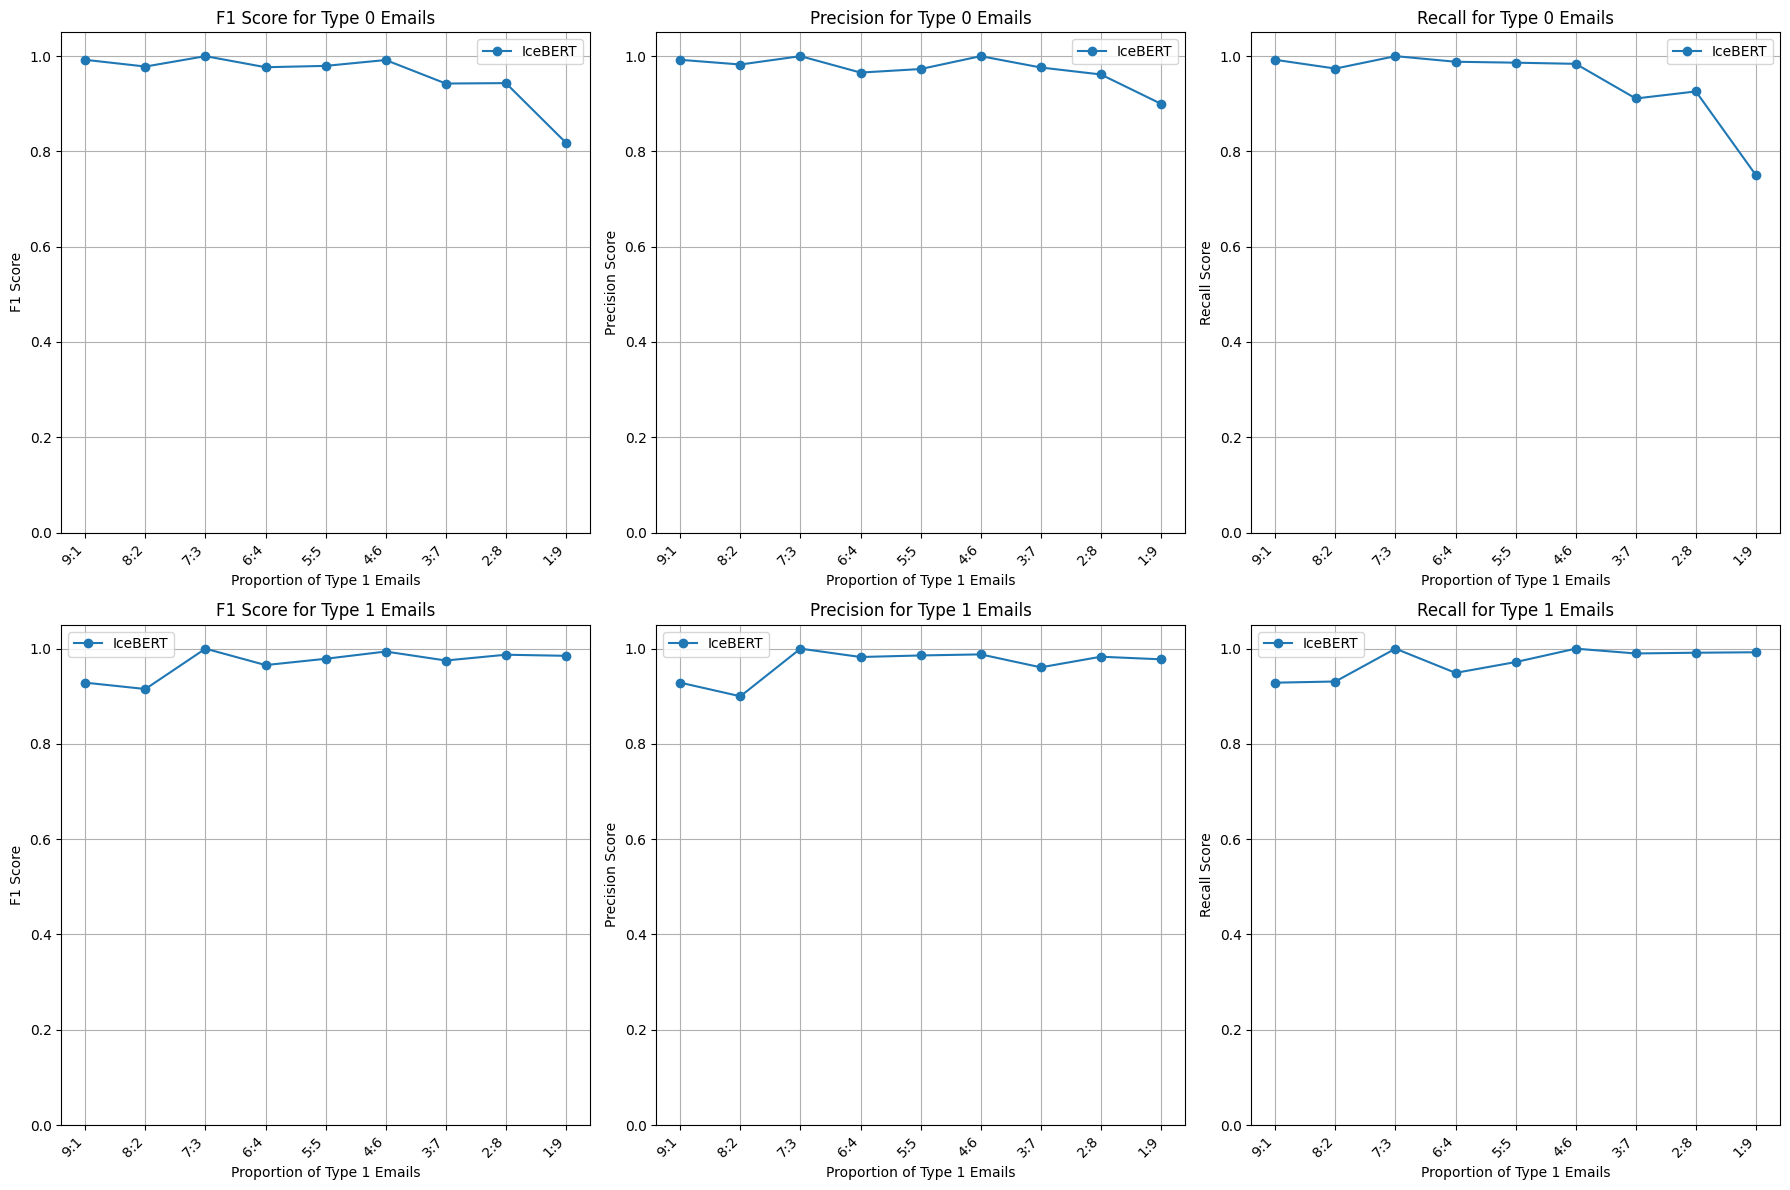

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, TrainingArguments, Trainer

# Ensure `icelandic` DataFrame and initial tokenizer/model are available from previous cells
# `icelandic` is already loaded and tokenized in previous cells.
# `tokenizer` and `model` are loaded and fine-tuned in previous cells.

# Store results
results = []
distributions_for_plot = [] # To store the (phishing_proportion) for x-axis values

# Define the ratios (Type 0:Type 1) as requested
ratios = [(9, 1), (8, 2), (7, 3), (6, 4), (5, 5), (4, 6), (3, 7), (2, 8), (1, 9)]

# Separate original data by type from the `icelandic` DataFrame
df_normal_all = icelandic[icelandic['type'] == 0]
df_phishing_all = icelandic[icelandic['type'] == 1]

max_normal_samples = len(df_normal_all)
max_phishing_samples = len(df_phishing_all)

print(f"Starting experiment with {len(ratios)} distributions...")
print(f"Total normal samples available: {max_normal_samples}")
print(f"Total phishing samples available: {max_phishing_samples}")

# Helper function to prepare data for Hugging Face Dataset (reusing from previous cells)
def prepare_data_for_dataset(df):
    return [{'input_ids': tokens, 'labels': label} for tokens, label in zip(df['tokenized_body'], df['type'])]

for r0, r1 in ratios:
    # Calculate proportion of Type 1 (phishing) emails
    phishing_proportion = r1 / (r0 + r1)
    distributions_for_plot.append(phishing_proportion)

    # Determine the number of samples for each class based on the requested proportions
    # Apply the ratio to the maximum available samples for each class independently.
    num_normal_actual = int(max_normal_samples * (r0 / (r0 + r1)))
    num_phishing_actual = int(max_phishing_samples * (r1 / (r0 + r1)))

    # Ensure at least 1 sample if ratio implies presence, to avoid issues with empty datasets
    if r0 > 0 and num_normal_actual == 0: num_normal_actual = 1
    if r1 > 0 and num_phishing_actual == 0: num_phishing_actual = 1

    print(f"\nProcessing distribution {r0}:{r1} (Type 0:Type 1). Actual samples: Type 0={num_normal_actual}, Type 1={num_phishing_actual}. Total: {num_normal_actual + num_phishing_actual}")

    # Sample from the original dataframes
    # Use a try-except block to handle cases where sampling might fail if num_samples is 0 or negative
    try:
        df_normal_sampled = df_normal_all.sample(n=num_normal_actual, random_state=42) if num_normal_actual > 0 else pd.DataFrame()
        df_phishing_sampled = df_phishing_all.sample(n=num_phishing_actual, random_state=42) if num_phishing_actual > 0 else pd.DataFrame()
    except ValueError as e:
        print(f"Error sampling for ratio {r0}:{r1}: {e}. Skipping this ratio.")
        continue

    current_df = pd.concat([df_normal_sampled, df_phishing_sampled]).sample(frac=1, random_state=42).reset_index(drop=True)

    if current_df.empty:
        print(f"Combined DataFrame is empty for ratio {r0}:{r1}. Skipping.")
        continue

    print("Class distribution in current dataset:\n", current_df['type'].value_counts())

    # Convert sampled DataFrame to Hugging Face Dataset format
    sampled_dataset_dict = Dataset.from_list(prepare_data_for_dataset(current_df))

    # Split the dataset into training and evaluation sets (using 10% for test)
    split_result_ratio = sampled_dataset_dict.train_test_split(test_size=0.1, seed=42)
    train_dataset_ratio = split_result_ratio['train']
    eval_dataset_ratio = split_result_ratio['test']

    print(f"Training dataset size for {r0}:{r1}: {len(train_dataset_ratio)}")
    print(f"Evaluation dataset size for {r0}:{r1}: {len(eval_dataset_ratio)}")

    if len(train_dataset_ratio) == 0 or len(eval_dataset_ratio) == 0:
        print(f"Not enough data for training/evaluation for ratio {r0}:{r1}. Skipping.")
        continue

    current_tokenizer = AutoTokenizer.from_pretrained("mideind/IceBERT")
    current_model = AutoModelForSequenceClassification.from_pretrained("mideind/IceBERT", num_labels=2)

    # Initialize data collator for Sequence Classification
    current_data_collator = DataCollatorWithPadding(
        tokenizer=current_tokenizer,
        padding=True,
        max_length=current_tokenizer.model_max_length, # Let it handle dynamic padding
        return_tensors="pt"
    )

    # Define training arguments for the current ratio experiment
    current_training_args = TrainingArguments(
        output_dir=f"./icebert_finetuned_classifier_ratio_{r0}_{r1}", # Unique output directory
        num_train_epochs=3, # adjust as needed
        per_device_train_batch_size=8,
        logging_steps=500,
        save_strategy="no", # No need to save checkpoint for each ratio
        report_to="none" # Disable reporting to services like Weights & Biases
    )

    # Initialize the Trainer for the current ratio
    trainer_ratio = Trainer(
        model=current_model,
        args=current_training_args,
        data_collator=current_data_collator,
        train_dataset=train_dataset_ratio,
        eval_dataset=eval_dataset_ratio,
    )

    print(f"  Training IceBERT for ratio {r0}:{r1}...")
    trainer_ratio.train()

    # Get predictions from the trainer
    predictions = trainer_ratio.predict(eval_dataset_ratio)
    logits = predictions.predictions
    predicted_labels = np.argmax(logits, axis=-1)

    # Get true labels
    true_labels = eval_dataset_ratio['labels']

    # Calculate metrics for class 0 (Normal)
    f1_0 = f1_score(true_labels, predicted_labels, pos_label=0, zero_division=0)
    precision_0 = precision_score(true_labels, predicted_labels, pos_label=0, zero_division=0)
    recall_0 = recall_score(true_labels, predicted_labels, pos_label=0, zero_division=0)

    # Calculate metrics for class 1 (Phishing)
    f1_1 = f1_score(true_labels, predicted_labels, pos_label=1, zero_division=0)
    precision_1 = precision_score(true_labels, predicted_labels, pos_label=1, zero_division=0)
    recall_1 = recall_score(true_labels, predicted_labels, pos_label=1, zero_division=0)

    results.append({
        'Distribution_Ratio_Type0_Type1': f"{r0}:{r1}",
        'Type1_Proportion': phishing_proportion,
        'Model': "IceBERT",
        'F1_Class_0': f1_0,
        'Precision_Class_0': precision_0,
        'Recall_Class_0': recall_0,
        'F1_Class_1': f1_1,
        'Precision_Class_1': precision_1,
        'Recall_Class_1': recall_1
    })
    print(f"    F1 (Class 0): {f1_0:.4f}, Precision (Class 0): {precision_0:.4f}, Recall (Class 0): {recall_0:.4f}")
    print(f"    F1 (Class 1): {f1_1:.4f}, Precision (Class 1): {precision_1:.4f}, Recall (Class 1): {recall_1:.4f}")

results_df = pd.DataFrame(results)
print("\n--- Experiment Results Summary ---")
print(results_df.to_string(index=False))

# Plotting
plt.figure(figsize=(18, 12)) # Increased figure size

# F1 for Class 0 (Normal)
plt.subplot(2, 3, 1)
for model_name in results_df['Model'].unique():
    model_data = results_df[results_df['Model'] == model_name].sort_values(by='Type1_Proportion')
    plt.plot(model_data['Type1_Proportion'], model_data['F1_Class_0'], label=model_name, marker='o')
plt.title('F1 Score for Type 0 Emails')
plt.xlabel('Proportion of Type 1 Emails')
plt.ylabel('F1 Score')
plt.xticks(distributions_for_plot, [f"{r[0]}:{r[1]}" for r in ratios], rotation=45, ha='right')
plt.grid(True)
plt.legend()
plt.ylim(0, 1.05)

# Precision for Class 0 (Normal)
plt.subplot(2, 3, 2)
for model_name in results_df['Model'].unique():
    model_data = results_df[results_df['Model'] == model_name].sort_values(by='Type1_Proportion')
    plt.plot(model_data['Type1_Proportion'], model_data['Precision_Class_0'], label=model_name, marker='o')
plt.title('Precision for Type 0 Emails')
plt.xlabel('Proportion of Type 1 Emails')
plt.ylabel('Precision Score')
plt.xticks(distributions_for_plot, [f"{r[0]}:{r[1]}" for r in ratios], rotation=45, ha='right')
plt.grid(True)
plt.legend()
plt.ylim(0, 1.05)

# Recall for Class 0 (Normal)
plt.subplot(2, 3, 3)
for model_name in results_df['Model'].unique():
    model_data = results_df[results_df['Model'] == model_name].sort_values(by='Type1_Proportion')
    plt.plot(model_data['Type1_Proportion'], model_data['Recall_Class_0'], label=model_name, marker='o')
plt.title('Recall for Type 0 Emails')
plt.xlabel('Proportion of Type 1 Emails')
plt.ylabel('Recall Score')
plt.xticks(distributions_for_plot, [f"{r[0]}:{r[1]}" for r in ratios], rotation=45, ha='right')
plt.grid(True)
plt.legend()
plt.ylim(0, 1.05)

# F1 for Class 1 (Phishing)
plt.subplot(2, 3, 4)
for model_name in results_df['Model'].unique():
    model_data = results_df[results_df['Model'] == model_name].sort_values(by='Type1_Proportion')
    plt.plot(model_data['Type1_Proportion'], model_data['F1_Class_1'], label=model_name, marker='o')
plt.title('F1 Score for Type 1 Emails')
plt.xlabel('Proportion of Type 1 Emails')
plt.ylabel('F1 Score')
plt.xticks(distributions_for_plot, [f"{r[0]}:{r[1]}" for r in ratios], rotation=45, ha='right')
plt.grid(True)
plt.legend()
plt.ylim(0, 1.05)

# Precision for Class 1 (Phishing)
plt.subplot(2, 3, 5)
for model_name in results_df['Model'].unique():
    model_data = results_df[results_df['Model'] == model_name].sort_values(by='Type1_Proportion')
    plt.plot(model_data['Type1_Proportion'], model_data['Precision_Class_1'], label=model_name, marker='o')
plt.title('Precision for Type 1 Emails')
plt.xlabel('Proportion of Type 1 Emails')
plt.ylabel('Precision Score')
plt.xticks(distributions_for_plot, [f"{r[0]}:{r[1]}" for r in ratios], rotation=45, ha='right')
plt.grid(True)
plt.legend()
plt.ylim(0, 1.05)

# Recall for Class 1 (Phishing)
plt.subplot(2, 3, 6)
for model_name in results_df['Model'].unique():
    model_data = results_df[results_df['Model'] == model_name].sort_values(by='Type1_Proportion')
    plt.plot(model_data['Type1_Proportion'], model_data['Recall_Class_1'], label=model_name, marker='o')
plt.title('Recall for Type 1 Emails')
plt.xlabel('Proportion of Type 1 Emails')
plt.ylabel('Recall Score')
plt.xticks(distributions_for_plot, [f"{r[0]}:{r[1]}" for r in ratios], rotation=45, ha='right')
plt.grid(True)
plt.legend()
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

In [16]:
plt.show()